**About Project:**
Marketing campaigns are a critical business activity for customer acquisition and retention in the banking sector. Financial institutions are increasingly relying on data-driven decision-making to enhance campaign effectiveness, reduce costs, and target the right customers.

The Bank Marketing team calls customers to encourage them to subscribe to a term deposit. They do not want to call all new and old customers without any insight. It will cost them a lot of money and time.

The objective of this project is to optimize the bank’s telemarketing efforts for term deposit subscriptions.

My primary machine learning model is a **supervised classification learning model** to predict whether a customer will subscribe to a term deposit. This model will help identify which features most strongly influence customer decisions and provide insight into the effectiveness of campaigns.

I will also train an **unsupervised clustering model** to create customer segments. The bank can prioritize customer segments during telemarketing campaigns to increase conversion rates and reduce marketing costs. They can target the lower-performing segment using alternative low-cost channels.

**About Dataset**:
I am picking a dataset from the UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/222/bank+marketing). The dataset contains information on direct marketing campaigns (phone calls) conducted by a Portuguese bank to predict whether a customer will subscribe to a term deposit.
The dataset contains nearly 45,000 observations, with each unit of analysis representing a customer contact made via telephone.

bank-full.csv with all examples, ordered by date (from May 2008 to November 2010).

Target "y": has the client subscribed a term deposit? (binary: "yes","no")

In [103]:
# Importing all the libraries
import pandas as pd
import random as rnd
import numpy as np
import seaborn as sns
import logging
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import roc_curve, auc

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


from sklearn import set_config

set_config(display='text')
pd.set_option('display.max_columns',50) # setting up the dataframe display columns
pd.set_option('display.max_colwidth', 100) # setting up column width 100


### Loading data file

I downloaded and copied bank-full.csv file from UCI Machine Learning Repository

In [104]:
file_bank= 'bank-full.csv' # file is saved in current directory.

# Catch any exception reading file
try:
    df_bank = pd.read_csv(f"{file_bank}", sep = ";")
except FileNotFoundError as e: # if file is not not found. 
    logging.error(f"{file_bank} is not found, please check the file path or name.\n{e}")

In [105]:
df_bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


**Attribute/Features Information:**
- 1  age: (numeric)
- 2  job: type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student","blue-collar","self-employed","retired","technician","services") 
- 3  marital: marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
- 4  education (categorical: "unknown","secondary","primary","tertiary")
- 5  default: has credit in default? (binary: "yes","no")
- 6  balance: average yearly balance, in euros (numeric) 
- 7  housing: has housing loan? (binary: "yes","no")
- 8  loan: has personal loan? (binary: "yes","no")

**related with the last contact of the current campaign:**
- 9  contact: contact communication type (categorical: "unknown","telephone","cellular") 
- 10 day: last contact day of the month (numeric)
- 11 month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
- 12 duration: last contact duration, in seconds (numeric)

**other attributes:**
- 13 campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
- 14 pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
- 15 previous: number of contacts performed before this campaign and for this client (numeric)
- 16 poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

**Output variable (desired target):**
- 17 y: has the client subscribed a term deposit? (binary: "yes","no")

**Missing values**: There are several missing values in some categorical attributes, all coded with the "unknown" label.

### Exploratory Data Analysis (EDA)
Milestone 3

Analyzing, data cleaning, and visualizing datasets and identifying underlying patterns of the data.

In [106]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


I do find any NaN values.

In [107]:
# Checking any duplicate
df_bank.duplicated().sum() 

np.int64(0)

In [108]:
# target variable distribution in raw dataset
df_bank['y'].value_counts(normalize=True)

y
no    0.8830
yes   0.1170
Name: proportion, dtype: float64

It is highly imbalance target class dataset. There is 88.3% non term deposit and 11.6% term deposit

In [157]:
# Checking 'unknown' values which represent missing data
print("\n'unknown' values count:")
for col in df_bank.columns:
    count = (df_bank[col] == 'unknown').sum()
    if count > 0:
        print(f"{col}: {count}")


'unknown' values count:
job: 288
education: 1857
contact: 13020
poutcome: 36959


**poutcome**: It has too many missing values, so I can drop the poutcome columns.

** job**: I have only 288 unknown values, and I can drop those records- unit of analysis.

**duration**: Notes from UCI that this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the call ends, y is obviously known. Thus, this input should be included only for benchmarking and discarded if the intention is to build a realistic predictive model.

In [110]:
df1 = df_bank.copy()

Dropping 'poutcome' and 'duration' columns, and dropping rows where 'job' is 'unknown'

In [111]:
# Dropping 'poutcome' and 'duration' columns
df1 = df1.drop(columns=['poutcome','duration'])

# Dropping rows where 'job' is 'unknown'
df1 = df1[df1['job'] != 'unknown']

In [112]:
# After removing 'job' = 'unknown', and dropping 'poutcome' and 'duration' columns
df1.shape

(44923, 15)

In [113]:
# Descriptive statistics for numeric columns
print("Descriptive statistics:")
df1.describe()

Descriptive statistics:


,age,balance,day,campaign,pdays,previous
count,44923.0000,44923.0000,44923.0000,44923.0000,44923.0000,44923.0000
mean,40.8935,1359.6430,15.8139,2.7603,40.3210,0.5820
std,10.6044,3045.0915,8.3200,3.0928,100.2551,2.3091
min,18.0000,-8019.0000,1.0000,1.0000,-1.0000,0.0000
25%,33.0000,72.0000,8.0000,1.0000,-1.0000,0.0000
50%,39.0000,447.0000,16.0000,2.0000,-1.0000,0.0000
75%,48.0000,1421.0000,21.0000,3.0000,-1.0000,0.0000
max,95.0000,102127.0000,31.0000,63.0000,871.0000,275.0000


**"age"** range is 18–95, with the average age being 41 and Interquartile Range (IQR), which represents the middle 50% of the dataset’s distribution is between 33 and 48 years old.

**"balances"** shows significant outliers, with a maximum value of 102,127  and some clients are in debt with negative balances.

**"pdays"** value of -1 means no prior campaign contact, many individuals are new prospects, evidenced by the median 

**"campaign"** mean is 3 contacts per client, though extreme outliers reach up to 63 contacts.

**"previous"** max is 275 previous contacts and it must be some outliers.

Standardization is mandatory for modeling, as high-value features like balance would otherwise mathematically overwhelm smaller numeric features like age.

#### IQR statistics: Outliers analysis based on data summary statistics 


Q1 = 0.25 and Q3 = 0.75
IQR Outlier Summary:
               Q1        Q3       IQR  Lower Bound  Upper Bound  Outlier Count
age      33.0000   48.0000   15.0000      10.5000      70.5000       480.0000
balance  72.0000 1421.0000 1349.0000   -1951.5000    3444.5000      4712.0000
day       8.0000   21.0000   13.0000     -11.5000      40.5000         0.0000
campaign  1.0000    3.0000    2.0000      -2.0000       6.0000      3031.0000
pdays    -1.0000   -1.0000    0.0000      -1.0000      -1.0000      8224.0000
previous  0.0000    0.0000    0.0000       0.0000       0.0000      8224.0000


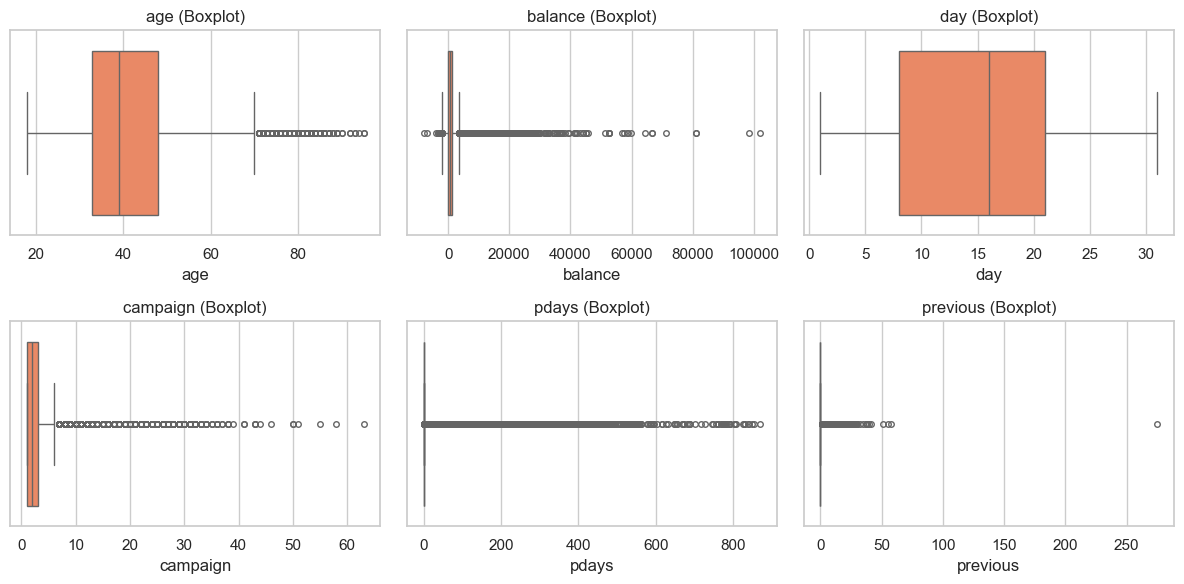

In [114]:
numeric_cols = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

# Function to calculate IQR bounds and detect outliers
lower_limit = 0.25
upper_limit = 0.75
def detect_outliers_iqr(data, column, lower_limit, upper_limit):
    Q1 = data[column].quantile(lower_limit)
    Q3 = data[column].quantile(upper_limit)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return Q1, Q3, IQR, lower_bound, upper_bound, outliers

# store results
iqr_results = {}
for col in numeric_cols:
    Q1, Q3, IQR, lower, upper, outliers = detect_outliers_iqr(df1, col, lower_limit, upper_limit )
    iqr_results[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Lower Bound': lower, 'Upper Bound': upper,'Outlier Count': len(outliers) }

# dataframe with IQR summary
iqr_df = pd.DataFrame(iqr_results).T
print(f"\nQ1 = {lower_limit} and Q3 = {upper_limit}\nIQR Outlier Summary:\n", iqr_df)

# Boxplots 
plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df1[col], color='coral', fliersize=4)
    plt.title(f'{col} (Boxplot)')
plt.tight_layout()
plt.show()


"balance" outliers are 4712, and Upper Bound is only usd 3,444, but some clients have usd 100,000+. I can cap the balance at a logical threshold (e.g., the 95th percentile, around $15,000) and will apply a log or sqrt transformation.

"campaign" 3031 people were called more than 6 times, calling "10 calls" or "60 calls" is the same "high engagement". I can delete any rows where "campaign" > 10

"pdays" and "previous" outliers are 8000+ because the IQR is 0. This happens because most people have 0 previous contacts. I will create a new column **pdays_connect** as "0" for new customers and "1" for returning customers.

In [115]:
numeric_cols = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

lower_limit = 0.25
upper_limit = 0.95
iqr_results = {}
for col in numeric_cols:
    Q1, Q3, IQR, lower, upper, outliers = detect_outliers_iqr(df1, col, lower_limit, upper_limit )
    iqr_results[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Lower Bound': lower, 'Upper Bound': upper,'Outlier Count': len(outliers) }

# dataframe with IQR summary
iqr_df = pd.DataFrame(iqr_results).T
print(f"\nQ1 = {lower_limit} and Q3 = {upper_limit}\nIQR Outlier Summary:\n", iqr_df)


Q1 = 0.25 and Q3 = 0.95
IQR Outlier Summary:
               Q1        Q3       IQR  Lower Bound  Upper Bound  Outlier Count
age      33.0000   59.0000   26.0000      -6.0000      98.0000         0.0000
balance  72.0000 5763.0000 5691.0000   -8464.5000   14299.5000       372.0000
day       8.0000   29.0000   21.0000     -23.5000      60.5000         0.0000
campaign  1.0000    8.0000    7.0000      -9.5000      18.5000       329.0000
pdays    -1.0000  318.0000  319.0000    -479.5000     796.5000        11.0000
previous  0.0000    3.0000    3.0000      -4.5000       7.5000       582.0000


In [116]:
df2 = df1.copy()
df2 = df2[df2['balance'] <= 15000] # Select only where balance <= 15000

df2 = df2[df2['campaign'] <= 10] # Select only where campaign <= 10

# Feature Engineering: Create the Binary Flag
# 0 = New Customer, 1 = Returning Customer
df2['pdays_connect'] = df2['pdays'].apply(lambda x: 0 if x == -1 else 1)

In [117]:
df1[(df1['previous'] > 60 )]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,y
29182,40,management,married,tertiary,no,543,yes,no,cellular,2,feb,2,262,275,no


I will drop the unit of analysis where "previous" > 60. It is an outlier.

In [118]:
# dropping outlier
df2 = df2[df2['previous'] <= 60]

In [119]:
print("Descriptive statistics after Outlier removing:")
df2.describe()

Descriptive statistics after Outlier removing:


,age,balance,day,campaign,pdays,previous,pdays_connect
count,43402.0000,43402.0000,43402.0000,43402.0000,43402.0000,43402.0000,43402.0000
mean,40.8723,1187.2072,15.6515,2.3801,41.3395,0.5887,0.1875
std,10.6116,2016.4827,8.2709,1.7680,101.2827,1.9247,0.3903
min,18.0000,-8019.0000,1.0000,1.0000,-1.0000,0.0000,0.0000
25%,33.0000,72.0000,8.0000,1.0000,-1.0000,0.0000,0.0000
50%,39.0000,444.0000,16.0000,2.0000,-1.0000,0.0000,0.0000
75%,48.0000,1390.0000,21.0000,3.0000,-1.0000,0.0000,0.0000
max,95.0000,14968.0000,31.0000,10.0000,871.0000,58.0000,1.0000


#### Checking Skewness

In [120]:
numeric_cols1 = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
numeric_cols2 = ['age', 'balance', 'day', 'campaign', 'pdays_connect', 'previous']

# Calculate skewness for both
skew_before = df1[numeric_cols1].skew()
skew_after = df2[numeric_cols2].skew()

# Create a comparison table
pd.DataFrame({'Skewness Before Outlier': skew_before,'Skewness After Outlier Removing': skew_after})

,Skewness Before Outlier,Skewness After Outlier Removing
age,0.6892,0.6892
balance,8.3901,2.9400
campaign,4.9110,1.8090
day,0.0922,0.1127
pdays,2.6079,NaN
pdays_connect,NaN,1.6015
previous,41.8027,7.6879


**Pearson correlation coefficient**

Measures the strength and direction of a linear relationship between variables, scaled between -1 and 1.

I will calculate the correlation coefficient on the scaled dataframe.

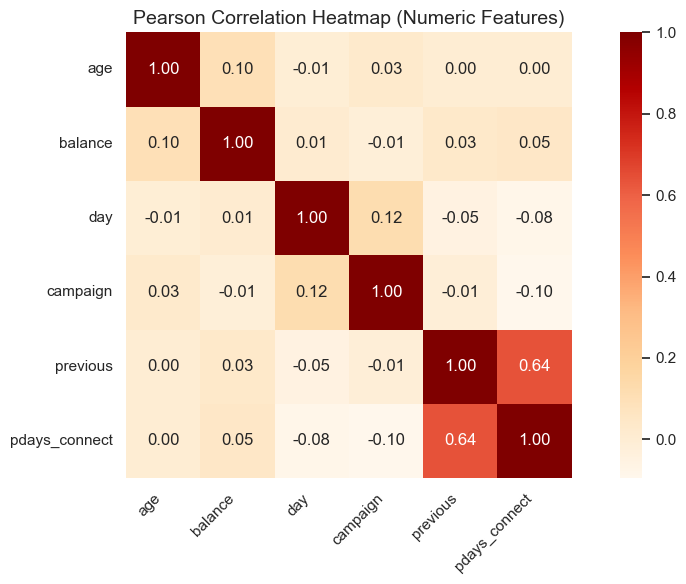

In [121]:
# Compute correlation matrix
numeric_cols = ['age', 'balance', 'day', 'campaign', 'previous', 'pdays_connect']
corr_matrix = df2[numeric_cols].corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="OrRd", cbar=True, square=True)
plt.title("Pearson Correlation Heatmap (Numeric Features)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**All correlations are well below 0.65, We do not have high multicollinearity from the correlation matrix.**

**Spearman correlation coefficient**

Spearman correlation measures the strength and direction of a monotonic relationship (not just linear).
It works on ranks, so it’s less sensitive to outliers.

We are using Label Encoding, since Spearman correlation needs numeric inputs to compute ranks.

One-hot encoding is not used here because that would produce many binary columns, making the Spearman matrix complex.

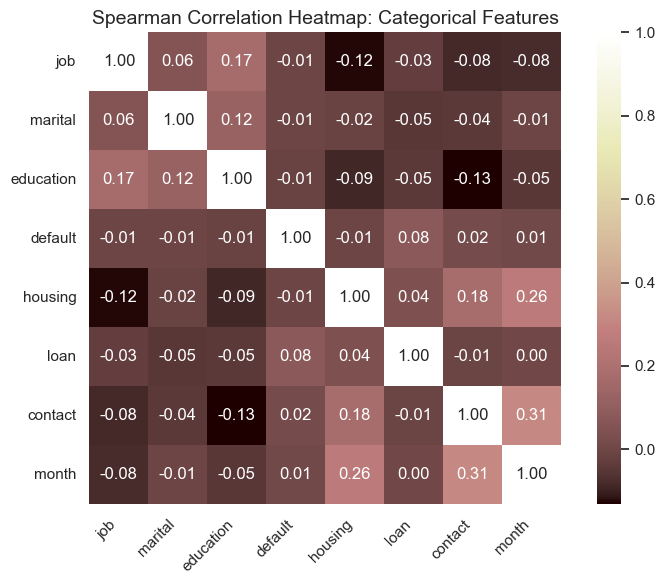

In [122]:
from sklearn.preprocessing import LabelEncoder

df_spearman = df2.copy() # copy original DataFrame

# Categorical columns to check (no income here)
categorical_cols =  ['job', 'marital', 'education', 'default', 'housing', 'loan','contact','month']

le = LabelEncoder() # Encode categorical variables
for col in categorical_cols:
    df_spearman[col] = le.fit_transform(df_spearman[col])

# Calculate Spearman correlation matrix
spearman_corr = df_spearman[categorical_cols].corr(method='spearman')

# Plot heatmap for categorical features only
plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="pink", cbar=True, square=True)
plt.title("Spearman Correlation Heatmap: Categorical Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Spearman correlation explains that most categorical features are largely independent of each other.

#### Histogram Visualizations

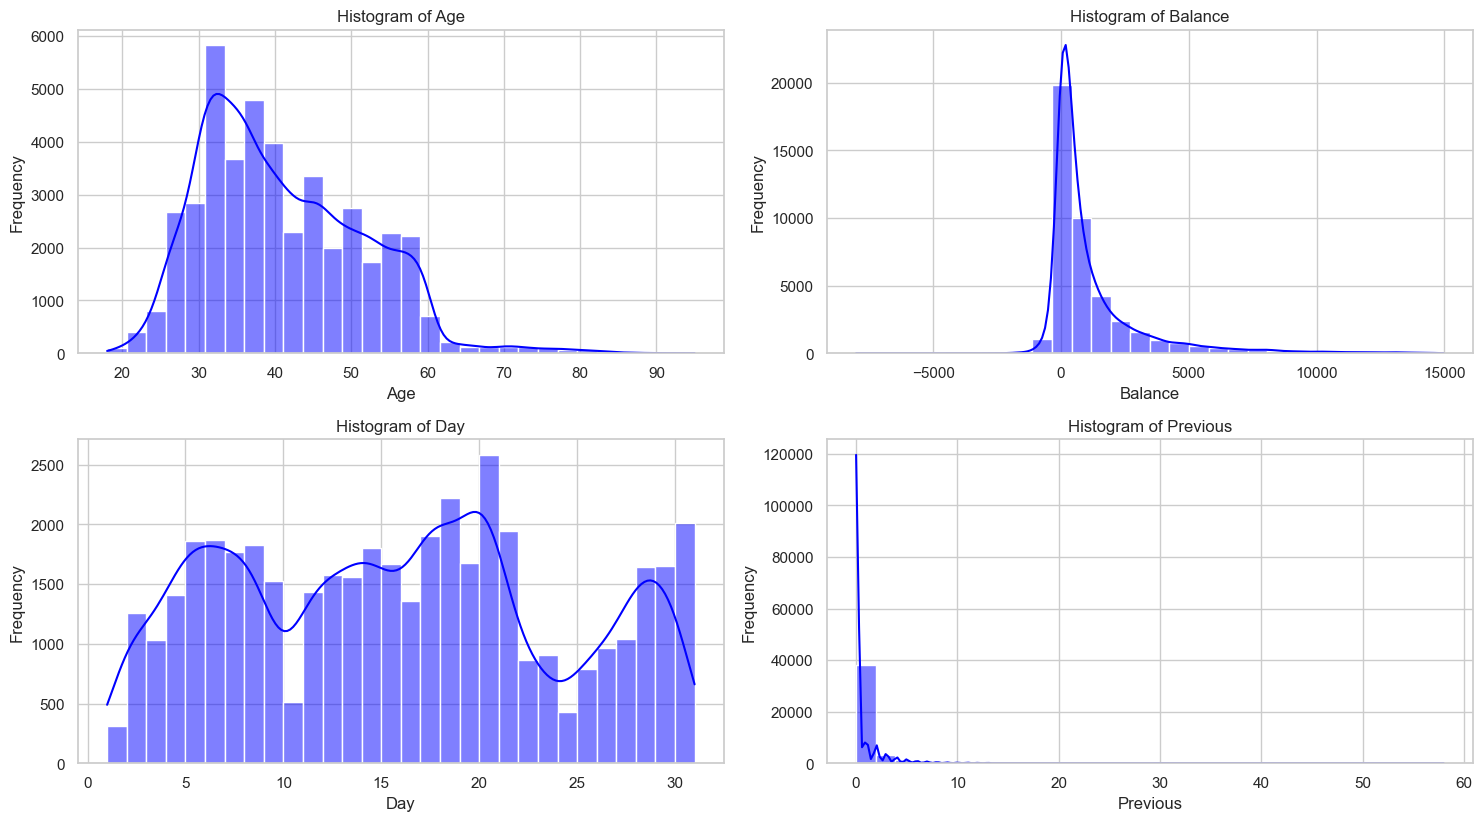

In [123]:
numeric_cols = ['age', 'balance', 'day', 'previous']

sns.set_theme(style="whitegrid")
# Create histograms
plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 2, i + 1)
    sns.histplot(df2[col], kde=True, color='blue', bins=30)
    plt.title(f'Histogram of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

I will apply MinMax Scaling and Log or SQRT transformation.

**Campaign is now a Ordinal Categorical value, and Pdays is binary values**

#### Categorical Value's Visualization

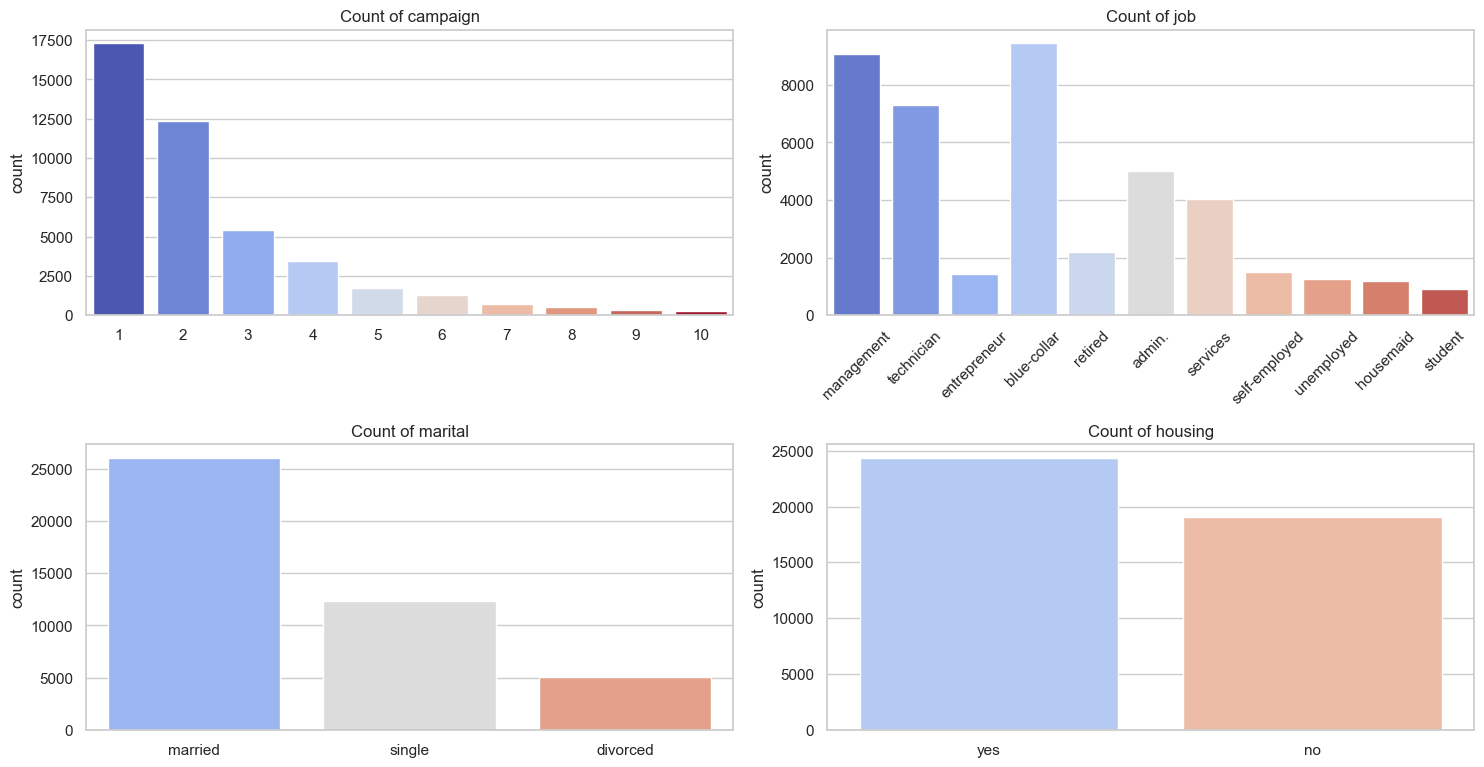

In [124]:
# List of the columns to visualize
cols = ['campaign', 'job', 'marital', 'housing']

# Create the canvas
plt.figure(figsize=(15, 20))

# Loop through each column and draw a simple bar graph
for i, col in enumerate(cols):
    plt.subplot(5, 2, i + 1)
    
    sns.countplot(data=df2, x=col, hue=col, palette='coolwarm', legend=False)
    
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45 if col == 'job' else 0)
    plt.xlabel('')

plt.tight_layout()
plt.show()

In [125]:
df2['y'].value_counts(normalize=True)

y
no    0.8809
yes   0.1191
Name: proportion, dtype: float64

In [126]:
df2.shape

(43402, 16)

### Model Selection, Training and Evaluation
Milestone 4

I will train and compare multiple algorithms to find the best model for the bank's imbalanced dataset.

In Exploratory Data Analysis, I performed data cleaning.
- Dropped 'poutcome' and 'duration' columns
- Dropped rows where 'job' is 'unknown'.
- Handled outliers by dropping rows where
  - balance > 15000,
  - campaign > 10
  - previous > 60.
- Created a new binary feature pdays_connect where 0 = New Customer and 1 = Returning Customer

There are few outliers in Age, and I am going to drop rows where age > 83. 

In [127]:
num_col = 'age'

lower_limit, upper_limit = 0.25, 0.85
iqr_results = {}
Q1, Q3, IQR, lower, upper, outliers = detect_outliers_iqr(df2, num_col, 
                                                          lower_limit, upper_limit )
iqr_results[num_col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Lower Bound': lower, 
                        'Upper Bound': upper,'Outlier Count': len(outliers) }

# dataframe with IQR summary
iqr_df = pd.DataFrame(iqr_results).T
print(f"Q1 = {lower_limit} and Q3 = {upper_limit} \nAge IQR Outlier Summary:\n", iqr_df)

Q1 = 0.25 and Q3 = 0.85 
Age IQR Outlier Summary:
          Q1      Q3     IQR  Lower Bound  Upper Bound  Outlier Count
age 33.0000 53.0000 20.0000       3.0000      83.0000        37.0000


In [128]:
df3 = df2.copy()

# Selecing rows, age <= 83
df3 = df3[df3['age']<= 83]

In [129]:
# dropping pdays feature, I have new feature 'pdays_connect'.

df3 = df3.drop(columns=['pdays'], errors='ignore')

In [130]:
numeric_cols = ['age', 'balance', 'day', 'campaign', 'previous']

df3[numeric_cols].skew()

age        0.6432
balance    2.9403
day        0.1127
campaign   1.8090
previous   7.6934
dtype: float64

Campaign is a Ordinal Categorical value. I can avoid it's skewness.

Age looks good.
I am correcting and checking the skewness of balance and previous with Log transformation.

In [131]:
df4 = df3.copy()
num_cols = ['balance', 'previous']

# Lifting balance above zero first since it has negatives
shift_bal = abs(df4['balance'].min()) 
df4['balance'] = df4['balance'] + shift_bal

num_pipeline = make_pipeline(
    FunctionTransformer(np.log1p, validate=True), # Log transformation
    MinMaxScaler(feature_range=(0, 1))
)

df4[num_cols] = num_pipeline.fit_transform(df4[num_cols])
df4[num_cols].skew()

balance    -0.9256
previous    2.4568
dtype: float64

We are able to reduce the skewness of 'balance' and 'previous' significanlty using log transformation.

**Here, log transformation on whole dataset is only for data analysis and understanding purpose. In actual model learning process, I will spilt the data into train and test to avoid any data leakages.**

*Log transformation does not do data leakage itself, but here I am calculating min() from whole dataset. It is a tiny data leakage issue.*

## Model Preparation
Target Variable
y: has the client subscribed a term deposit? (binary: "yes","no")

In [132]:
# copying the dataframe
df_lr = df3.copy()

df_lr.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,previous,y,pdays_connect
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,0,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,0,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,0,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,0,no,0
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,1,0,no,0


In [133]:
# defining numeric and categorical features
num_cols = ['age', 'balance', 'day', 'campaign', 'previous','pdays_connect']
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','month']

#### Seperating Input and Target Features 

In [134]:
# target feature
y = df_lr['y'].map({'yes': 1, 'no': 0})

# Input features
X = df_lr.drop('y', axis=1)

#### Spliting dataset into train and test

In [135]:
# Splitting dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y
                                                   )



#### Shifting the balacne by adding abs(min) values for log transformation

In [136]:
shift_bal = abs(X_train['balance'].min()) 

X_train['balance_shift'] = X_train['balance'] + shift_bal

X_test['balance_shift'] = X_test['balance'] + shift_bal

I am shifting the balance by min balance to avoid error in log transformation.

Log does work for values > 0.


#### Creating Model Preprocessing Pipeline

In [137]:
# Pipeline for the skewed columns (Balance & Previous)
log_scaling_pipe = Pipeline([
                ('apply_log', FunctionTransformer(np.log1p, validate=True,
                                                 feature_names_out='one-to-one')),
                ('min_max_scale',MinMaxScaler(feature_range=(0, 1)))
                ])

# The ColumnTransformer 
preprocessor = ColumnTransformer(
    transformers=[
        # Applying the Log-Scaler to only balance and previous
        ('log_vars', log_scaling_pipe, ['balance_shift', 'previous']),

        # Min-Max Scaling 
        ('min_max', MinMaxScaler(feature_range=(0, 1)), ['age', 'day', 'campaign','pdays_connect']),
        
        # Hot encode the categories
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ]
)


### Logistics Regression - Classification

I have  imbalanced classes and have not addressed it during preprocessing. I am using the class_weight parameter to weight the classes to make certain I have a balanced mix of each class. Specifically, the balanced argument automatically adjust weights for each class, making them inversely proportional to their frequency in the training data. 

This technique is used to handle class imbalance, a common problem where some classes have many more samples than others.

In [138]:
# Logistics Regressoin
# Model with balancing 
logit_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_pipe_balanced = Pipeline([('prep', preprocessor), 
                             ('model', logit_balanced)])

# Model wihtout balancing 
logit_default = LogisticRegression(max_iter=1000, random_state=42, class_weight=None)
lr_pipe_default = Pipeline([('prep', preprocessor), 
                            ('model', logit_default)])

# Model training and prediction 
lr_pipe_balanced.fit(X_train, y_train)
y_pred_lr_balanced = lr_pipe_balanced.predict(X_test)

lr_pipe_default.fit(X_train, y_train)
y_pred_lr_default = lr_pipe_default.predict(X_test)


print("Model-1: Logistic Regression with CLASS_WEIGHT='balanced':")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_balanced):.2%}")

cls_report_lr_wgt = classification_report(y_test, y_pred_lr_balanced)
print(cls_report_lr_wgt)

print("\nModel-2 Logistic Regression with CLASS_WEIGHT (default):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_default):.2%}")

cls_report_lr_def = classification_report(y_test, y_pred_lr_default)
print(cls_report_lr_def)

Model-1: Logistic Regression with CLASS_WEIGHT='balanced':
Accuracy: 70.69%
              precision    recall  f1-score   support

           0       0.94      0.71      0.81      7643
           1       0.24      0.66      0.35      1030

    accuracy                           0.71      8673
   macro avg       0.59      0.69      0.58      8673
weighted avg       0.86      0.71      0.76      8673


Model-2 Logistic Regression with CLASS_WEIGHT (default):
Accuracy: 88.35%
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      7643
           1       0.55      0.11      0.18      1030

    accuracy                           0.88      8673
   macro avg       0.72      0.55      0.56      8673
weighted avg       0.85      0.88      0.85      8673



Model-1 Logistic Regression Model with CLASS_WEIGHT='balanced' accuracy 70.69% is lower than CLASS_WEIGHT (default) 88.35%.

*However Model-1 has a highest Recall = 0.66 value, even though the overall accuracy is lower. This model-1 is 6 times more effective at identifying revenue for the bank.*


### K-Nearest Neighbors (KNN) - Classification
I am using K-Nearest Neighbors (KNN) for my classification problem to imporve the model accuracy.

Standard KNeighborsClassifier does not have a class_weight parameter. Since KNN is a distance-based and lazy learner.

In [139]:
# Defining new pipeline for KNN model
knn_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', KNeighborsClassifier(n_jobs = -1))
])

# Search Space for KNN
knn_param_grid = {
    'model__n_neighbors': [1,2,3,4,5,6,7,8,9,10],  # Number of neighbors
    'model__weights': ['uniform', 'distance'], # Whether closer neighbors count more
    'model__metric': ['euclidean', 'manhattan'] # Distance measure algorithm
}

In [140]:
# Creating grid search- KNN Model
knn_grid = GridSearchCV(knn_pipe, knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fitting grid search- KNN
knn_grid.fit(X_train, y_train);

In [141]:
print(f"K-Nearest Neighbors (KNN):")
print(f"Best Hyperparameters: {knn_grid.best_params_}")
print(f"KNN CV Accuracy: {knn_grid.best_score_:.2%}")

# predicting test value- Random Forest
y_pred_knn = knn_grid.predict(X_test)
cls_report_knn = classification_report(y_test, y_pred_knn)
print("\nKNN classification report:\n",cls_report_knn)


K-Nearest Neighbors (KNN):
Best Hyperparameters: {'model__metric': 'manhattan', 'model__n_neighbors': 8, 'model__weights': 'uniform'}
KNN CV Accuracy: 88.21%

KNN classification report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94      7643
           1       0.54      0.12      0.20      1030

    accuracy                           0.88      8673
   macro avg       0.72      0.55      0.57      8673
weighted avg       0.85      0.88      0.85      8673



### Random Forest Classifier- Model Ensemble

***I can try the model ensemble technique to imporve the the model accuracy on class_weight='balanced'***.
I am using Random Forest Classifier.

A Random Forest Classifier is an ensemble learning method that aggregates predictions from a multitude of individual decision trees to produce a more accurate and stable classification.

In [142]:
# Defining new pipeline for the Random Forest model
rf_pipe = Pipeline([
    ('prep', preprocessor), 
    ('model', RandomForestClassifier(random_state=42, 
                                     class_weight='balanced'
                                     , n_jobs = -1)) 
])

# Search Space Random Forest
rf_param_grid = {
    'model__n_estimators': [10,50,100],  # Number of trees
    'model__max_depth': [6, 10, 15],     # How deep each tree goes
    'model__min_samples_split': [2, 5]   # Minimum data points to make a split
}

# Creating grid search- Random Forest
rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fitting grid search- Random Forest
rf_grid.fit(X_train, y_train);

In [143]:
print(f"Model Ensemble Random Forest:")
print(f"  Best Hyperparameters: {rf_grid.best_params_}")
print(f"  Random Forest CV Accuracy: {rf_grid.best_score_:.2%}")

# predicting test value- Random Forest
y_pred_rf = rf_grid.predict(X_test)
cls_report_rf = classification_report(y_test, y_pred_rf)
print("\nRandom Forest classification report:\n", cls_report_rf)


Model Ensemble Random Forest:
  Best Hyperparameters: {'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 100}
  Random Forest CV Accuracy: 85.85%

Random Forest classification report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.92      7643
           1       0.40      0.48      0.44      1030

    accuracy                           0.85      8673
   macro avg       0.67      0.69      0.68      8673
weighted avg       0.87      0.85      0.86      8673



***Classification Model Selection***

Logistic Regressoin with class_weight='balanced' has accuracy 70.69% and KNN has accuracy = 88.21%. However I like to propose Random Forest classifier model.

**Random Forest has the accuracy 85.85% lower than KNN and Logistic Regressoin but it has the highest F1-Score 0.44 for class 1 (yes). It offers the best balance between finding subscribers and being accurate.**

F1 = 2 * (Precision * Recall) / (Precision + Recall) 
Precision = tp / (tp + fp)
Recall = tp / (tp + fn)

In the bank, calling a customer cost both money and time. Random Forest has precision = 0.40, it means 4 out of every 10 customer will likely subscribe the term deposit if I call them. Random Forest has recall = 0.48 higher than KNN.

KNN has high precision = 0.54 but it has a low recall = 0.12 also.         

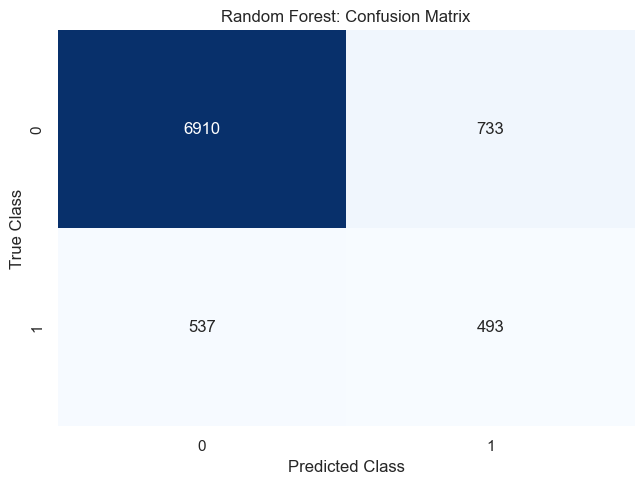

In [144]:
# confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# create confusion matrix
conf_df = pd.DataFrame(conf_matrix_rf, index = rf_grid.classes_, columns = rf_grid.classes_)

# Decimal places and no scientific notation
pd.options.display.float_format = '{:.4f}'.format

# create heatmap
sns.heatmap(conf_df, annot = True, fmt = 'd', cbar = None, cmap = "Blues")
plt.title("Random Forest: Confusion Matrix")
plt.tight_layout()
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

Bank can achieve a 40% success rate per call, identifying nearly half of all potential subscribers while avoiding 90% of uninterested customers.

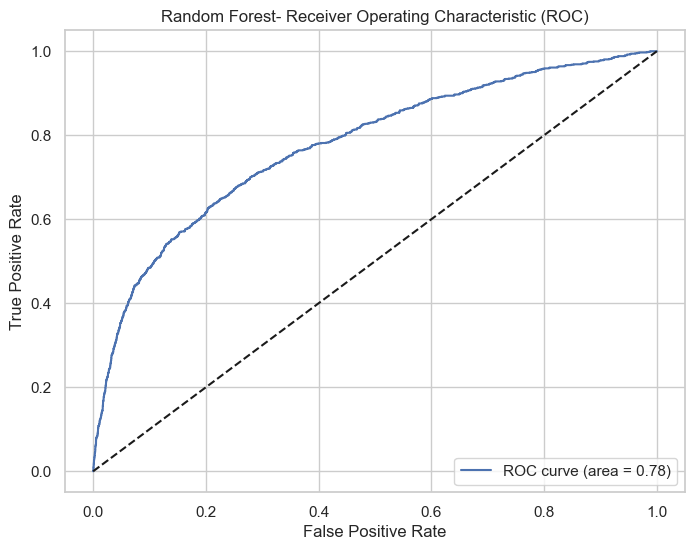

The AUC Score is: 0.7760


In [145]:
# ROC Curve
y_prob = rf_grid.predict_proba(X_test)[:,1] # Get probability for the positive class

# create true and false positive rates 
false_positive_rate, true_positive_rate, threshold = roc_curve(y_test, y_prob )

roc_auc = auc(false_positive_rate, true_positive_rate)

plt.figure(figsize=(8, 6))
plt.plot(false_positive_rate, true_positive_rate, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Diagonal line representing random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest- Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Add this line to see the result
print(f"The AUC Score is: {roc_auc:.4f}")

The model achieved an AUC-ROC of 0.7760. It is able to discriminate between potential subscribers and non-subscribers. The model's predictions are superior than random chance (0.50)

### Interpretation- Finding Most Important Input Features

In [146]:
# Getting the best estimator from Random Forest GridSearch
best_pipeline = rf_grid.best_estimator_

# Getting features names
feature_names = best_pipeline.named_steps['prep'].get_feature_names_out()

# Getting important features
importances = best_pipeline.named_steps['model'].feature_importances_

# Creating  DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Important input features for for Class 1
print(feature_importance_df.head(10))


                    Feature  Importance
0   log_vars__balance_shift      0.1311
2              min_max__age      0.1244
3              min_max__day      0.1069
25     cat__contact_unknown      0.0762
22         cat__housing_yes      0.0637
1        log_vars__previous      0.0566
4         min_max__campaign      0.0550
5    min_max__pdays_connect      0.0405
33           cat__month_may      0.0286
23            cat__loan_yes      0.0246


**Classification Model Summary:** 

The Random Forest model is a good choice for this bank marketing project because it offers the strongest balance between efficiency and opportunity, achieving an F1-score of 0.44 and an AUC of 0.7760. It has a per-call success rate, precision = 40% while still capturing nearly half of all potential subscribers. This performance is primarily driven by customer balance, age, and specific timing factors, such as the day of the call.

Balance and age are the most important input features for Term deposit subscriptions. Random Forest model also relies on timing and engagement patterns, such as the specific day of the call and the history of previous bank interactions, to distinguish potential subscribers.

It is also clear that a customer should have a bank balance for the Term deposit, and age also matters for it.

### KMeans Clustering
Using K-Means clustering, I am creating a customer segment. I can prioritize customer segments during telemarketing campaigns to increase conversion rates and reduce marketing costs. I can target the lower-performing segment using alternative low-cost channels.

#### Searching optimal K value using silhouette_score

For k=2, the Silhouette Score is: 0.1348
For k=3, the Silhouette Score is: 0.1191
For k=4, the Silhouette Score is: 0.1122
For k=5, the Silhouette Score is: 0.1228


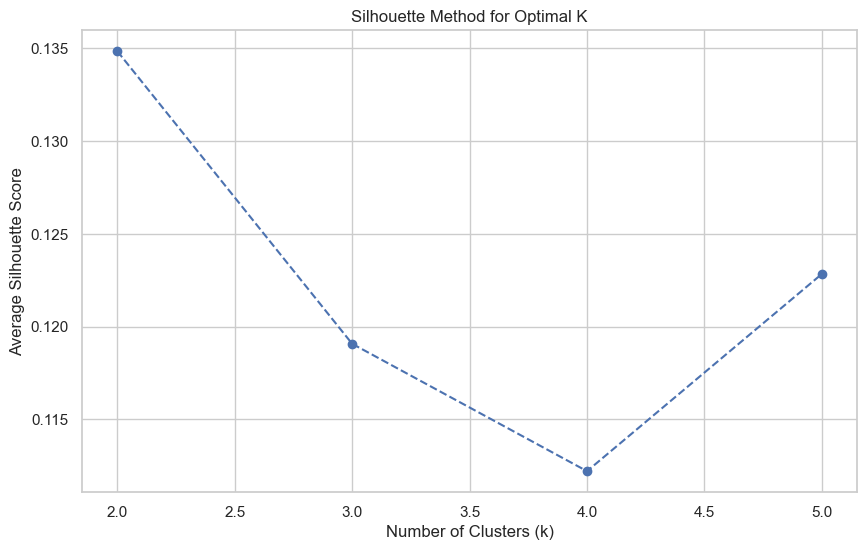

In [148]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# empty list to store scores
sil_scores = []
k_range = range(2, 6) # Silhouette score requires at least 2 clusters

# Tranformed the trainig data using preprocessor
X_km = preprocessor.fit_transform(X_train)

# Loop potential cluster numbers
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_km)
    
    # Calculate the average score for this k
    score = silhouette_score(X_km, cluster_labels)
    sil_scores.append(score)
    print(f"For k={k}, the Silhouette Score is: {score:.4f}")

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, sil_scores, marker='o', linestyle='--', color='b')
plt.title('Silhouette Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.grid(True)
plt.show()

Silhouette coefficient is used to measure the quality of the clusters. 

The value returned by the silhouette_score is the mean silhouette coefficient for all observations, with a silhouette coefficient range between -1 and 1, with 1 indicating dense, well-separated clusters.

Here, clusters = 2 has the highest positive values, so I will pick cluster = 2.

#### Training K-Means model 

In [149]:
# KMeans model, cluster  = 2
kmeans_model = KMeans(n_clusters=2, random_state=42, n_init=10)

# Scaling the input features
X_train_scale = preprocessor.fit_transform(X_train)

# fitting and predicitng the model, finding cluster labels
cluster_labels = kmeans_model.fit_predict(X_train_scale)

In [150]:
# cluster labels or training dataset
pd.Series(cluster_labels).value_counts() # training dataset

1    24146
0    10546
Name: count, dtype: int64

K-Means is unsupervised and we do not know the actual target labels, it just groups by feature similarity.

We are adding target label "y".

In [151]:
# Creating a copy of X_train
X_train_clustered = X_train.copy()

# Add cluster labels
X_train_clustered['cluster_label'] = kmeans_model.labels_

# Adding target value
X_train_clustered['y'] = y_train.values

new_order = [ 'cluster_label', 'y', 'age', 'job', 'marital', 'education', 'default', 
              'balance', 'balance_shift', 'housing', 'loan', 'contact', 'day', 
              'month', 'campaign', 'previous', 'pdays_connect'
            ]

X_train_clustered = X_train_clustered[new_order]

X_train_clustered.head()

,cluster_label,y,age,job,marital,education,default,balance,balance_shift,housing,loan,contact,day,month,campaign,previous,pdays_connect
20644,0,0,31,management,single,tertiary,no,391,8410,yes,no,cellular,12,aug,3,0,0
26743,1,0,58,blue-collar,divorced,primary,no,2716,10735,no,no,cellular,20,nov,2,0,0
30945,1,0,60,technician,married,secondary,no,21,8040,no,no,telephone,9,feb,4,0,0
1772,1,0,43,housemaid,married,primary,no,1342,9361,yes,yes,unknown,9,may,2,0,0
18843,1,0,31,technician,married,secondary,no,6699,14718,no,no,cellular,4,aug,1,0,0


In [152]:
# Conversion rate
cluster_summary = X_train_clustered.groupby('cluster_label')['y'].mean()
cluster_summary

cluster_label
0   0.1552
1   0.1027
Name: y, dtype: float64

Cluster label 0 is the more responsive segment, with approximately 15.5% of customers subscribing compared to 10.3% in Cluster 1.
Bank can capture a higher concentration of successful conversions and optimizing marketing resources. Focusing on cluster label 0 allows the sales team to prioritize leads that have 1.5 higher chances to subscribe than those in Cluster 1.

***fowlkes_mallows_score*** is a metric used to evaluate how well KMeans clusters (unsupervised) match with train or test target label (supervised).

I am predicting the cluster lable against the training data, and we can do the same for test data also.

In [153]:
from sklearn.metrics import fowlkes_mallows_score

fmi = fowlkes_mallows_score(y_train, cluster_labels)
print("Fowlkes–Mallows Index:", fmi)

Fowlkes–Mallows Index: 0.6859361055575094


This score means there is a 68.6% similarity between how the K-Means grouped the customers and how customer responses actually Subscribed vs. Not Subscribed term deposit. 

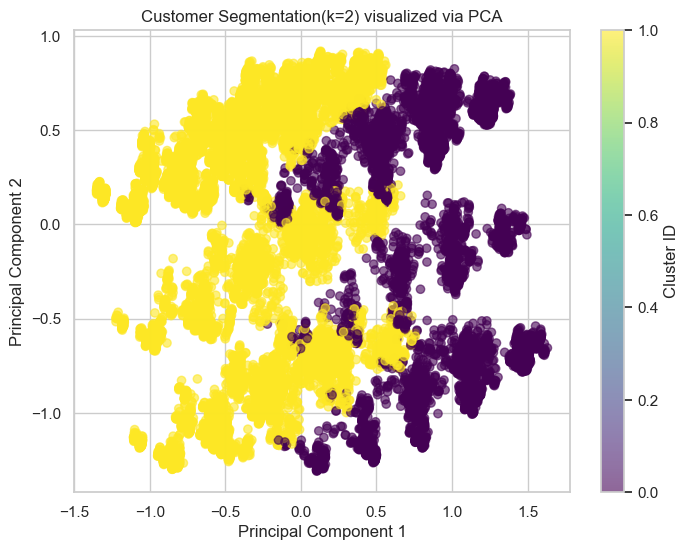

In [154]:
from sklearn.decomposition import PCA
# PCA Transformation
optimal_k = 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scale)

# Scatterplot of PCA data colored by Cluster
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Customer Segmentation(k={optimal_k}) visualized via PCA')
plt.colorbar(label='Cluster ID')
plt.show()

PCA visualization confirms that the K-Means algorithm successfully identified two distinct customer segments based on a combination of financial and demographic features.

### Conclusion and Findings

The objective of this project was to build a machine learning model that predicts whether a bank customer will subscribe to a term deposit based on information collected during direct marketing campaigns. It is important to predict potential subscribers because telemarketing campaigns require significant time and financial resources.

I tried multiple supervised classification models, including Logistic Regression, K-Nearest Neighbors (KNN), and Random Forest. I proposed the Random Forest classification model because it provided the best balance between finding subscribers and accuracy.

Random Forest achieved an accuracy = 85.85% and produced the highest F1-score = 0.44 for the positive class ("yes"), which represents customers who subscribe to a term deposit. The F1-score provides a good measure because it balances precision and recall. The Random Forest model achieved a precision of 0.40, meaning that approximately 4 out of every 10 customers predicted to subscribe actually do subscribe.

The model also interpreted customers' financial status, age, and demographics as the primary factors of a term deposit subscription. The model's prediction also depends on the timing of the call and the history of previous interactions.

I also trained a K-Means cluster model. The model explained that Cluster 0 is the more responsive segment, achieving a subscription rate of 15.5%, compared to 10.3% in Cluster 1. The bank can focus on Cluster 0 and optimize marketing resources and capture a higher percentage of successful conversions. Fowlkes–Mallows Index (FMI) score = 0.6859 indicates similarity between two sets of groups. I can visualize this grouping using Principal Component Analysis (PCA).